In [27]:
import pandas as pd
from tashaphyne.stemming import ArabicLightStemmer
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../datasets/Arabic_Poetry_Dataset.csv")

In [3]:
list_of_requierd = ["قصائد غزل","قصائد هجاء","قصائد مدح","قصائد رثاء"]

In [8]:
# to view all categories in the dataset
tsnef = []
andalus = df[df["poet_era"] == "العصر الأندلسي"]
for x in range(len(andalus["poem_tags"])):
    tsnef.append(andalus["poem_tags"].iloc[x].split(",")[0])
aa = pd.DataFrame({"a":tsnef})
aa["a"].unique()

array(['قصائد قصيره', 'قصائد مدح', 'قصائد وطنيه', 'قصائد عامه',
       'قصائد غزل', 'قصائد ذم', 'قصائد هجاء', 'قصائد رثاء', 'قصائد دينية',
       'قصائد حزينه', 'قصائد رومنسيه', 'قصائد فراق', 'قصائد شوق',
       'قصائد عتاب', 'قصائد ابتهال', 'قصائد نصيحة', 'قصائد حكمة',
       'قصائد صبر', 'قصائد جود وكرم', 'قصائد رحمة'], dtype=object)

In [ ]:
# to get the stem of the word
# pip install tashaphyne

class ArabicPoetryLightStemmer:
    
    def __init__(self):
        self.stemmer = ArabicLightStemmer()
    
    def light_stem(self, word):
        self.stemmer.light_stem(word)
        return {
            'original': word,
            'stem': self.stemmer.get_stem(),
            'prefix': self.stemmer.get_prefix(),
            'suffix': self.stemmer.get_suffix()
        }
    
    def stem_poem(self, poem_text):
        words = poem_text.split()
        stemmed_words = []
        
        for word in words:
            self.stemmer.light_stem(word)
            stemmed_words.append(self.stemmer.get_stem())
        
        return ' '.join(stemmed_words)
    
    def batch_stem_poems(self, poems_list):
        """Process multiple poems"""
        return [self.stem_poem(poem) for poem in poems_list]

stemmer = ArabicPoetryLightStemmer()


In [ ]:
# only andalusian poems are kept -> tshkeel removed -> removed stop words -> get stem of the words -> keep only poems of length less than 700 char

poem_with_type = pd.DataFrame()
andalus = df[df["poet_era"] == "العصر الأندلسي"]
poems_without_diact = []
types = []
meters = []
for x in range(len(andalus["poem_text"])):
    
    one_bait = andalus["poem_text"].iloc[x]
    cleaned_text = str(one_bait).replace('\n', ' ')
    text = re.sub(r'[\u064B-\u065F]', '', str(cleaned_text))
    tokens = word_tokenize(cleaned_text.lower())
    stop_words = set(stopwords.words('arabic'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    
    tokens_without_diact = word_tokenize(text.lower())
    
    filtered_tokens_without_diact = [word for word in tokens_without_diact if word not in stop_words]
    filtered_tokens_without_diact = [stemmer.light_stem(word)["stem"] for word in filtered_tokens_without_diact]
    
    filtered_tokens = ' '.join(filtered_tokens)
    filtered_tokens_without_diact = ' '.join(filtered_tokens_without_diact)
    if len(filtered_tokens) < 700 and andalus["poem_tags"].iloc[x].split(",")[0] in list_of_requierd:
        
        poems_without_diact.append(filtered_tokens_without_diact)
    
        types.append(andalus["poem_tags"].iloc[x].split(",")[0])
        # meters.append(detector.detect_meter(filtered_tokens)['meter'])


poem_with_type["poem"] = poems_without_diact
poem_with_type["type"] = types

In [12]:
df_sampled = poem_with_type.groupby('type').head(150)

In [14]:
vectorizer = TfidfVectorizer(ngram_range=(1,1))
X = vectorizer.fit_transform(df_sampled["poem"])

In [15]:
df_sampled["type"].value_counts()

type
قصائد مدح     150
قصائد هجاء    150
قصائد غزل     150
قصائد رثاء    103
Name: count, dtype: int64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, df_sampled["type"], test_size=0.2, random_state=42)

In [20]:
clf = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('clf', MultinomialNB()),
])

clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', MaxAbsScaler()), ('clf', MultinomialNB())])

In [23]:
accuracy = clf.score(X_train, y_train)
print(f"Train Accuracy: {accuracy * 100:.2f}%")
accuracy = clf.score(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Train Accuracy: 99.77%
Test Accuracy: 58.56%


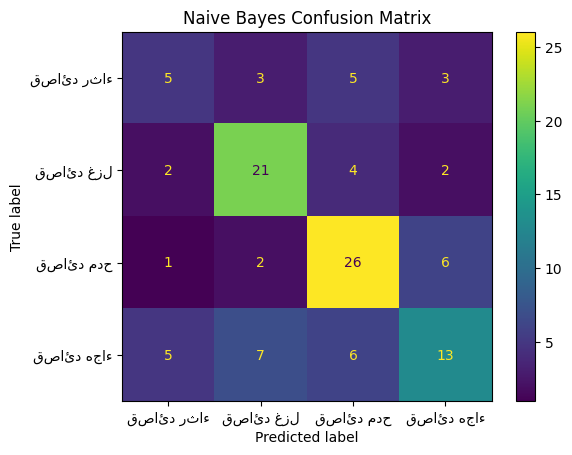

In [29]:
y_pred = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [38]:
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_clf = svm.SVC(kernel='linear', C=0.8, gamma='scale')

# 5. Train the model
svm_clf.fit(X_train_scaled, y_train)

# 6. Make predictions
y_pred = svm_clf.predict(X_test_scaled)

# 7. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy:.2%}')


Test Accuracy: 52.25%


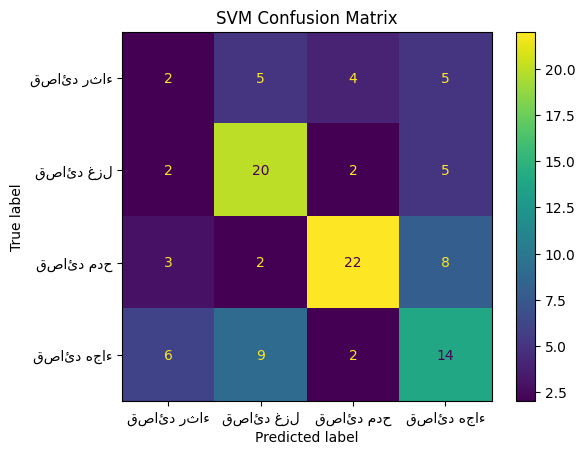

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('SVM Confusion Matrix')
plt.show()

In [43]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf1 = LogisticRegression(random_state=1)
clf2 = DecisionTreeClassifier(random_state=1)
clf3 = SVC(random_state=1, probability=True) # probability=True is needed for soft voting
clf4 = MultinomialNB()

eclf1 = VotingClassifier(
    estimators=[('lr', clf1), ('dt', clf2), ('svc', clf3), ('svca', clf4)],
    voting='soft', # Use 'soft' for probability averaging
    weights=[0.9, 0.2, 0.1, 0.9] # Optional: assign weights
)

# Train the ensemble model
eclf1.fit(X_train_scaled, y_train)

# Evaluate the model
score = eclf1.score(X_test_scaled, y_test)
print(f"Ensemble Classifier Accuracy: {score:.4f}")


Ensemble Classifier Accuracy: 0.5946
